### 导入包并初始化设备

In [1]:
# Cell 1: 安装依赖、挂载Google Drive、设置路径


import os
import json
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from transformers import BertTokenizer

# 挂载Google Drive
drive.mount('/content/drive')

# 设置数据路径（请根据实际位置修改）
DATA_PATH = './xjtu-ml-class/exp/data/SQuAD'
TRAIN_FILE = os.path.join(DATA_PATH, 'SQuAD-train-v2.0.json')
DEV_FILE = os.path.join(DATA_PATH, 'SQuAD-dev-v2.0.json')
CHECKPOINT_DIR = '/content/drive/MyDrive/SQuAD_checkpoints/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


### 定义数据集类与数据加载器

In [ ]:
# Cell 2
class SQuADDataset(Dataset):
    def __init__(self, json_path, tokenizer, max_length=384, is_train=True):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.is_train = is_train
        with open(json_path, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
        self.examples = self._extract_examples(raw_data)
        self.input_ids = []
        self.attention_mask = []
        self.start_positions = []
        self.end_positions = []
        self._tokenize()
        print(f"Loaded {len(self.examples)} valid examples from {json_path}")

    def _extract_examples(self, raw_data):
        examples = []
        for article in raw_data['data']:
            for para in article['paragraphs']:
                context = para['context']
                for qa in para['qas']:
                    if qa.get('is_impossible', False): continue
                    if not qa.get('answers'): continue
                    ans = qa['answers'][0]
                    examples.append({
                        'context': context,
                        'question': qa['question'],
                        'answer_text': ans['text'],
                        'answer_start_char': ans['answer_start']
                    })
        return examples

    def _tokenize(self):
        skipped = 0
        for ex in tqdm(self.examples, desc="Tokenizing"):
            enc = self.tokenizer(
                ex['question'], ex['context'],
                max_length=self.max_length,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
                return_offsets_mapping=True
            )
            ids = enc['input_ids'].squeeze(0)
            mask = enc['attention_mask'].squeeze(0)
            offsets = enc['offset_mapping'].squeeze(0).tolist()
            if self.is_train:
                start_char = ex['answer_start_char']
                end_char = start_char + len(ex['answer_text'])
                start_token, end_token = None, None
                for i, (tok_s, tok_e) in enumerate(offsets):
                    if tok_s == 0 and tok_e == 0: continue
                    if tok_s <= start_char < tok_e: start_token = i
                    if tok_s < end_char <= tok_e: end_token = i
                if start_token is None or end_token is None:
                    skipped += 1
                    continue
                self.start_positions.append(start_token)
                self.end_positions.append(end_token)
            self.input_ids.append(ids)
            self.attention_mask.append(mask)
        print(f"Skipped {skipped} examples (answer span not found)")
        self.input_ids = torch.stack(self.input_ids)
        self.attention_mask = torch.stack(self.attention_mask)
        if self.is_train:
            self.start_positions = torch.tensor(self.start_positions, dtype=torch.long)
            self.end_positions = torch.tensor(self.end_positions, dtype=torch.long)

    def __len__(self): return len(self.input_ids)
    def __getitem__(self, idx):
        if self.is_train:
            return {'input_ids': self.input_ids[idx], 'attention_mask': self.attention_mask[idx],
                    'start_pos': self.start_positions[idx], 'end_pos': self.end_positions[idx]}
        else:
            return {'input_ids': self.input_ids[idx], 'attention_mask': self.attention_mask[idx]}

def create_dataloaders(train_path, dev_path, batch_size=16, max_length=384):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    train_ds = SQuADDataset(train_path, tokenizer, max_length, is_train=True)
    dev_ds = SQuADDataset(dev_path, tokenizer, max_length, is_train=True)
    return DataLoader(train_ds, batch_size, shuffle=True), DataLoader(dev_ds, batch_size, shuffle=False), tokenizer

### 实现Transformer基类

In [ ]:
# Cell 3: Transformer 基础组件
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0
        self.d_model = d_model
        self.nhead = nhead
        self.d_k = d_model // nhead
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        Q = self.W_q(query).view(B, -1, self.nhead, self.d_k).transpose(1,2)
        K = self.W_k(key).view(B, -1, self.nhead, self.d_k).transpose(1,2)
        V = self.W_v(value).view(B, -1, self.nhead, self.d_k).transpose(1,2)
        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.d_k)

        if mask is not None:
            # 统一将 mask 转为 4D (B, 1, seq_q, seq_k) 或 (B, nhead, seq_q, seq_k)
            if mask.dim() == 2:
                # 可能是 (seq_len, seq_len) 或 (B, seq_len)
                if mask.size(0) != B and mask.size(1) == mask.size(0):
                    # 无 batch 维度的方阵 -> (1,1,seq_len,seq_len)
                    mask = mask.unsqueeze(0).unsqueeze(0)
                else:
                    # (B, seq_len) -> (B,1,1,seq_len)
                    mask = mask.unsqueeze(1).unsqueeze(2)
            elif mask.dim() == 3:
                # 可能是 (1, seq_len, seq_len) 或 (B, seq_q, seq_k)
                if mask.size(0) == 1 and mask.size(1) == mask.size(2):
                    mask = mask.unsqueeze(1)   # (1,1,seq_len,seq_len)
                else:
                    mask = mask.unsqueeze(1)   # (B,1,seq_q,seq_k)
            # 现在 mask 是 4D，广播到 nhead 维度
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = self.dropout(torch.softmax(scores, dim=-1))
        out = torch.matmul(attn, V).transpose(1,2).contiguous().view(B, -1, self.d_model)
        return self.W_o(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()
    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, nhead, dropout)
        self.ff = FeedForward(d_model, dim_feedforward, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout1(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout2(self.ff(x)))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, nhead, dropout)
        self.cross_attn = MultiHeadAttention(d_model, nhead, dropout)
        self.ff = FeedForward(d_model, dim_feedforward, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    def forward(self, x, encoder_output, self_mask=None, cross_mask=None):
        # 如果 self_mask 是 2D 方阵（无 batch 维），扩展为 (1,1,seq_len,seq_len)
        if self_mask is not None and self_mask.dim() == 2:
            self_mask = self_mask.unsqueeze(0).unsqueeze(0)
        x = self.norm1(x + self.dropout1(self.self_attn(x, x, x, self_mask)))
        x = self.norm2(x + self.dropout2(self.cross_attn(x, encoder_output, encoder_output, cross_mask)))
        x = self.norm3(x + self.dropout3(self.ff(x)))
        return x

### 实现QA模型1

In [ ]:
# Cell 4
class EncoderOnlyQA(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=6,
                 dim_feedforward=1024, max_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, nhead, dim_feedforward, dropout) for _ in range(num_layers)])
        self.start_out = nn.Sequential(nn.Linear(d_model, d_model//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model//2, 1))
        self.end_out = nn.Sequential(nn.Linear(d_model, d_model//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model//2, 1))
        self._init_weights()
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
    def forward(self, input_ids, attn_mask=None):
        x = self.embed(input_ids) * math.sqrt(self.d_model)
        x = self.pos(x)
        for layer in self.layers: x = layer(x, attn_mask)
        return self.start_out(x).squeeze(-1), self.end_out(x).squeeze(-1)

### 实现QA模型2

In [ ]:
# Cell 5: EncoderDecoderQA
class EncoderDecoderQA(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_encoder_layers=4, num_decoder_layers=4,
                 dim_feedforward=1024, max_len=512, dropout=0.1, max_answer_len=50,
                 cls_token_id=101, sep_token_id=102):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.max_answer_len = max_answer_len
        self.cls_token_id = cls_token_id
        self.sep_token_id = sep_token_id

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        self.pos_decoder = PositionalEncoding(d_model, max_len, dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_decoder_layers)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, vocab_size)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _get_causal_mask(self, size, device):
        # 返回 (size, size) 的下三角布尔掩码（True 表示可见）
        mask = torch.tril(torch.ones(size, size, device=device)).bool()
        return mask

    def encode(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        return x

    def decode(self, decoder_input, encoder_output, cross_mask=None):
        seq_len = decoder_input.size(1)
        device = decoder_input.device
        # 因果掩码形状 (seq_len, seq_len)，DecoderLayer 会自动扩展
        causal_mask = self._get_causal_mask(seq_len, device)
        x = self.embedding(decoder_input) * math.sqrt(self.d_model)
        x = self.pos_decoder(x)
        for layer in self.decoder_layers:
            x = layer(x, encoder_output, self_mask=causal_mask, cross_mask=cross_mask)
        return x

    def forward(self, input_ids, decoder_input_ids=None, attention_mask=None):
        enc_out = self.encode(input_ids, attention_mask)
        if decoder_input_ids is not None:
            dec_out = self.decode(decoder_input_ids, enc_out, attention_mask)
            logits = self.output_layer(dec_out)
            return logits
        else:
            return self.generate(enc_out, attention_mask)

    def generate(self, encoder_output, attention_mask=None):
        batch_size = encoder_output.size(0)
        device = encoder_output.device
        decoder_input = torch.full((batch_size, 1), self.cls_token_id, dtype=torch.long, device=device)
        for _ in range(self.max_answer_len):
            dec_out = self.decode(decoder_input, encoder_output, attention_mask)
            next_logits = self.output_layer(dec_out[:, -1, :])
            next_token = next_logits.argmax(dim=-1, keepdim=True)
            decoder_input = torch.cat([decoder_input, next_token], dim=1)
            if (next_token == self.sep_token_id).all():
                break
        return decoder_input

### 实现训练器Trainer

In [ ]:
# Cell 6
class QATrainer:
    def __init__(self, model, device=None):
        self.model = model.to(device or torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        self.device = next(model.parameters()).device
        self.train_losses, self.dev_losses, self.dev_accs = [], [], []
        self.best_acc, self.best_state = 0, None
        self.is_encdec = isinstance(model, EncoderDecoderQA)
        print(f"Trainer ready on {self.device}, model: {'EncDec' if self.is_encdec else 'EncOnly'}")

    def train(self, train_loader, dev_loader, epochs=10, lr=3e-4, opt='adamw', wd=0.01, clip=1.0, verbose=True):
        opt = self._get_opt(opt, lr, wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
        for ep in range(epochs):
            loss = self._train_epoch(train_loader, opt, clip, ep, epochs, verbose)
            metrics = self.evaluate(dev_loader)
            self.train_losses.append(loss)
            self.dev_losses.append(metrics['loss'])
            self.dev_accs.append(metrics['acc'])
            if metrics['acc'] > self.best_acc:
                self.best_acc = metrics['acc']
                self.best_state = {k:v.cpu().clone() for k,v in self.model.state_dict().items()}
            sched.step()
            if verbose:
                print(f"\nEpoch {ep+1}/{epochs}: Train Loss={loss:.4f}, Dev Loss={metrics['loss']:.4f}, Span Acc={metrics['acc']:.2f}%, LR={opt.param_groups[0]['lr']:.6f}")
        if self.best_state: self.model.load_state_dict(self.best_state)
        print(f"\n✅ Best span accuracy: {self.best_acc:.2f}%")
        return self

    def _train_epoch(self, loader, opt, clip, ep, total, verbose):
        self.model.train()
        total_loss = 0
        it = tqdm(loader, desc=f'Epoch {ep+1}/{total}') if verbose else loader
        for batch in it:
            ids = batch['input_ids'].to(self.device)
            mask = batch['attention_mask'].to(self.device)
            opt.zero_grad()
            if self.is_encdec:
                start = batch['start_pos'].to(self.device)
                end = batch['end_pos'].to(self.device)
                targets = [ids[i, start[i]:end[i]+1] for i in range(ids.size(0))]
                if any(len(t)==0 for t in targets): continue
                max_len = max(len(t) for t in targets)
                padded = torch.stack([torch.cat([t, torch.full((max_len-len(t),), 0, device=self.device)]) for t in targets])
                dec_in = padded[:, :-1]
                target = padded[:, 1:]
                if dec_in.size(1) == 0: continue
                logits = self.model(ids, dec_in, mask)
                loss = nn.CrossEntropyLoss(ignore_index=0)(logits.reshape(-1, self.model.vocab_size), target.reshape(-1))
            else:
                start, end = batch['start_pos'].to(self.device), batch['end_pos'].to(self.device)
                s_log, e_log = self.model(ids, mask)
                loss = nn.CrossEntropyLoss()(s_log, start) + nn.CrossEntropyLoss()(e_log, end)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), clip)
            opt.step()
            total_loss += loss.item()
            if verbose: it.set_postfix(loss=loss.item())
        return total_loss / max(len(loader), 1)

    def evaluate(self, loader):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for batch in tqdm(loader, desc="Evaluating", leave=False):
                ids = batch['input_ids'].to(self.device)
                mask = batch['attention_mask'].to(self.device)
                if self.is_encdec:
                    start, end = batch['start_pos'].to(self.device), batch['end_pos'].to(self.device)
                    targets = [ids[i, start[i]:end[i]+1] for i in range(ids.size(0))]
                    if any(len(t)==0 for t in targets): continue
                    max_len = max(len(t) for t in targets)
                    padded = torch.stack([torch.cat([t, torch.full((max_len-len(t),), 0, device=self.device)]) for t in targets])
                    dec_in = padded[:, :-1]
                    target = padded[:, 1:]
                    if dec_in.size(1) == 0: continue
                    logits = self.model(ids, dec_in, mask)
                    loss = nn.CrossEntropyLoss(ignore_index=0)(logits.reshape(-1, self.model.vocab_size), target.reshape(-1))
                    total_loss += loss.item()
                    gen = self.model.generate(self.model.encode(ids, mask), mask)
                    for i in range(ids.size(0)):
                        gen_seq = gen[i, 1:]   # remove leading [CLS]
                        ref_seq = padded[i]
                        min_len = min(len(gen_seq), len(ref_seq))
                        if min_len > 0 and torch.equal(gen_seq[:min_len], ref_seq[:min_len]):
                            correct += 1
                    total += ids.size(0)
                else:
                    start, end = batch['start_pos'].to(self.device), batch['end_pos'].to(self.device)
                    s_log, e_log = self.model(ids, mask)
                    loss = nn.CrossEntropyLoss()(s_log, start) + nn.CrossEntropyLoss()(e_log, end)
                    total_loss += loss.item()
                    pred_s, pred_e = s_log.argmax(-1), e_log.argmax(-1)
                    correct += ((pred_s == start) & (pred_e == end)).sum().item()
                    total += start.size(0)
        return {'loss': total_loss / max(len(loader),1), 'acc': 100.0 * correct / max(total,1)}

    def _get_opt(self, name, lr, wd):
        name = name.lower()
        if name == 'adam': return torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=wd)
        if name == 'adamw': return torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=wd)
        if name == 'sgd': return torch.optim.SGD(self.model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
        raise ValueError(f"Unknown optimizer: {name}")

    def save_model(self, path):
        torch.save({'model_state_dict': self.model.state_dict(),
                    'train_losses': self.train_losses, 'dev_losses': self.dev_losses,
                    'dev_accs': self.dev_accs, 'best_acc': self.best_acc}, path)
        print(f"Saved to {path}")

    def plot_history(self):
        fig, ax = plt.subplots(1,2,figsize=(12,4))
        ax[0].plot(self.train_losses, label='Train Loss')
        ax[0].plot(self.dev_losses, label='Dev Loss')
        ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend(); ax[0].grid(True)
        ax[1].plot(self.dev_accs, label='Span Accuracy')
        ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy (%)'); ax[1].legend(); ax[1].grid(True)
        plt.tight_layout(); plt.show()



### 实验

Tokenizing:   0%|          | 0/86821 [00:00<?, ?it/s]

Skipped 75 examples (answer span not found)
Loaded 86821 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-train-v2.0.json


Tokenizing:   0%|          | 0/5928 [00:00<?, ?it/s]

Skipped 24 examples (answer span not found)
Loaded 5928 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-dev-v2.0.json
Vocabulary size: 30522

=== Encoder-Only ===
Params: 4,716,546
Trainer ready on cuda:0, model: EncOnly


Epoch 1/3:   0%|          | 0/5422 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/369 [00:00<?, ?it/s]


Epoch 2/3: Train Loss=7.3564, Dev Loss=7.9261, Span Acc=4.30%, LR=0.000075


Epoch 3/3:   0%|          | 0/5422 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/369 [00:00<?, ?it/s]


Epoch 3/3: Train Loss=6.8321, Dev Loss=8.0723, Span Acc=5.06%, LR=0.000000

✅ Best span accuracy: 5.06%
Saved to /content/drive/MyDrive/SQuAD_checkpoints/EncoderOnlyQA.pt


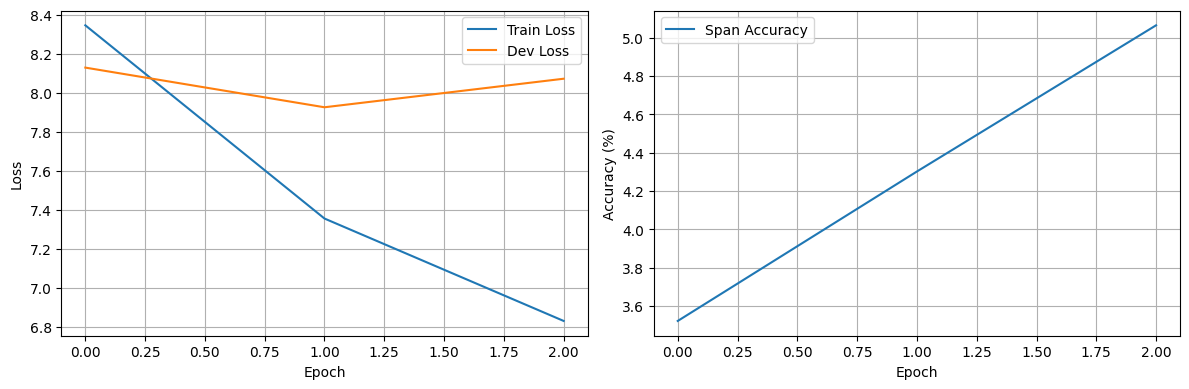


=== Encoder-Decoder ===
Params: 9,249,210
Trainer ready on cuda:0, model: EncDec


Epoch 1/3:   0%|          | 0/5422 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/369 [00:00<?, ?it/s]


Epoch 1/3: Train Loss=7.9537, Dev Loss=7.8284, Span Acc=0.00%, LR=0.000225


Epoch 2/3:   0%|          | 0/5422 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/369 [00:00<?, ?it/s]


Epoch 2/3: Train Loss=7.3514, Dev Loss=7.5650, Span Acc=0.00%, LR=0.000075


Epoch 3/3:   0%|          | 0/5422 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/369 [00:00<?, ?it/s]


Epoch 3/3: Train Loss=7.0395, Dev Loss=7.4941, Span Acc=0.00%, LR=0.000000

✅ Best span accuracy: 0.00%
Saved to /content/drive/MyDrive/SQuAD_checkpoints/EncoderDecoderQA.pt


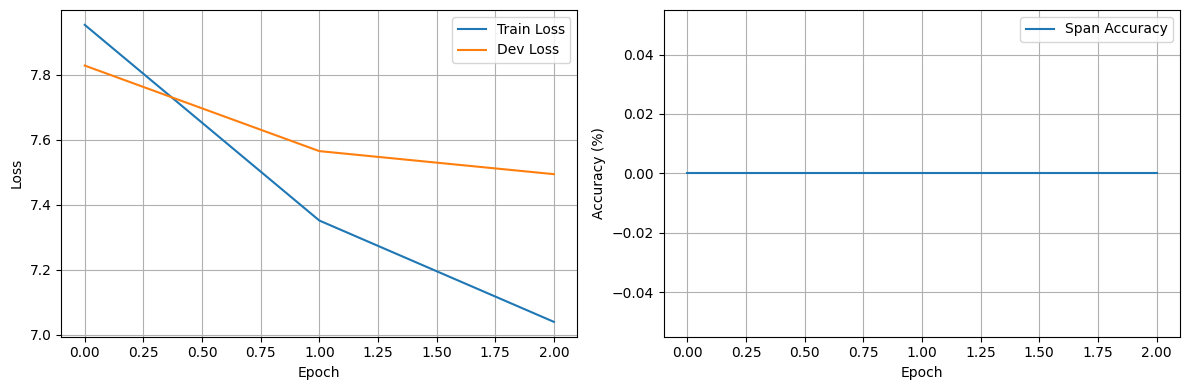


Final Results: EncOnly Acc=5.06%, EncDec Acc=0.00%


In [ ]:
# 主程序
if __name__ == "__main__":
    BATCH_SIZE, MAX_LEN, EPOCHS = 16, 384, 3   # 可调
    train_loader, dev_loader, tokenizer = create_dataloaders(TRAIN_FILE, DEV_FILE, BATCH_SIZE, MAX_LEN)
    vocab_size = tokenizer.vocab_size
    print(f"Vocabulary size: {vocab_size}")

    # Encoder-Only
    print("\n=== Encoder-Only ===")
    model1 = EncoderOnlyQA(vocab_size, d_model=128, nhead=8, num_layers=4, dim_feedforward=512, max_len=MAX_LEN, dropout=0.1)
    print(f"Params: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}")
    trainer1 = QATrainer(model1, device)
    trainer1.train(train_loader, dev_loader, epochs=EPOCHS, lr=3e-4, opt='adamw')
    trainer1.save_model(os.path.join(CHECKPOINT_DIR, "EncoderOnlyQA.pt"))
    trainer1.plot_history()

    # Encoder-Decoder
    print("\n=== Encoder-Decoder ===")
    model2 = EncoderDecoderQA(vocab_size, d_model=128, nhead=8, num_encoder_layers=3, num_decoder_layers=3,
                              dim_feedforward=512, max_len=MAX_LEN, dropout=0.1, max_answer_len=50,
                              cls_token_id=tokenizer.cls_token_id, sep_token_id=tokenizer.sep_token_id)
    print(f"Params: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")
    trainer2 = QATrainer(model2, device)
    trainer2.train(train_loader, dev_loader, epochs=EPOCHS, lr=3e-4, opt='adamw')
    trainer2.save_model(os.path.join(CHECKPOINT_DIR, "EncoderDecoderQA.pt"))
    trainer2.plot_history()

    print(f"\nFinal Results: EncOnly Acc={trainer1.best_acc:.2f}%, EncDec Acc={trainer2.best_acc:.2f}%")

### 测试2


In [ ]:
# 主实验
if __name__ == "__main__":
    print("="*70)
    print("SQuAD QA with Custom Transformers")
    print("="*70)

    BATCH_SIZE = 128
    MAX_LEN = 384
    EPOCHS = 10   # 可改为 5 或 10

    train_loader, dev_loader, tokenizer = create_dataloaders(
        TRAIN_FILE, DEV_FILE, batch_size=BATCH_SIZE, max_length=MAX_LEN
    )
    vocab_size = tokenizer.vocab_size
    print(f"Vocabulary size: {vocab_size}")

    # Encoder-Only
    print("\n" + "="*70)
    print("Experiment 1: Encoder-Only")
    model1 = EncoderOnlyQA(vocab_size, d_model=256, nhead=8, num_layers=6,
                           dim_feedforward=512, max_len=MAX_LEN, dropout=0.05)
    print(f"Params: {sum(p.numel() for p in model1.parameters() if p.requires_grad):,}")
    trainer1 = QATrainer(model1, device)
    trainer1.train(train_loader, dev_loader, epochs=EPOCHS, lr=6e-4, opt_name='adamw')
    trainer1.save_model(os.path.join(CHECKPOINT_DIR, "EncoderOnlyQA_dmodel256_lay6_batch128_epoch10_adamw_lr6_batch128.pt"))
    trainer1.plot_history()

    # Encoder-Decoder
    print("\n" + "="*70)
    print("Experiment 2: Encoder-Decoder")
    model2 = EncoderDecoderQA(vocab_size, d_model=256, nhead=8,
                              num_encoder_layers=3, num_decoder_layers=3,
                              dim_feedforward=512, max_len=MAX_LEN, dropout=0.1,
                              max_answer_len=50,
                              cls_token_id=tokenizer.cls_token_id,
                              sep_token_id=tokenizer.sep_token_id)
    print(f"Params: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")
    trainer2 = QATrainer(model2, device)
    trainer2.train(train_loader, dev_loader, epochs=EPOCHS, lr=3e-4, opt_name='sgd')
    trainer2.save_model(os.path.join(CHECKPOINT_DIR, "EncoderDecoderQA_dmodel256_lay3_epoch10_sgd_lr3_batch128.pt"))
    trainer2.plot_history()

    print("\n" + "="*70)
    print("Final Results")
    print(f"Encoder-Only    Best Span Acc: {trainer1.best_span_acc:.2f}%")
    print(f"Encoder-Decoder Best Span Acc: {trainer2.best_span_acc:.2f}%")
    print("="*70)

SQuAD QA with Custom Transformers


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing:   0%|          | 0/86821 [00:00<?, ?it/s]

Skipped 75 examples (answer span not found)
Loaded 86821 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-train-v2.0.json


Tokenizing:   0%|          | 0/5928 [00:00<?, ?it/s]

Skipped 24 examples (answer span not found)
Loaded 5928 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-dev-v2.0.json
Vocabulary size: 30522

Experiment 1: Encoder-Only
Params: 11,042,306
Trainer on cuda, model: EncOnly


Epoch 1/10:   0%|          | 0/678 [00:00<?, ?it/s]

### 展示

In [ ]:
# Cell 7: 加载模型并展示测试案例

def load_model_and_demo(model_path, model_type='encoder_only',
                        d_model=256, num_layers=6, nhead=8, max_len=384,
                        dim_feedforward=None):  # 新增参数
    """
    加载保存的模型并进行案例展示

    Args:
        model_path: 模型权重文件路径 (.pt)
        model_type: 'encoder_only' 或 'encoder_decoder'
        d_model, num_layers, nhead, max_len: 模型超参数（需与训练时一致）
        dim_feedforward: FFN维度，如果为None则使用 4*d_model
    """
    # 加载 tokenizer
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    vocab_size = tokenizer.vocab_size

    # 如果未指定，使用默认值
    if dim_feedforward is None:
        dim_feedforward = 4 * d_model

    # 创建模型
    if model_type == 'encoder_only':
        model = EncoderOnlyQA(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,  # 使用传入的值
            max_len=max_len,
            dropout=0.1
        )
    else:
        model = EncoderDecoderQA(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            max_len=max_len,
            dropout=0.1,
            max_answer_len=50,
            cls_token_id=tokenizer.cls_token_id,
            sep_token_id=tokenizer.sep_token_id
        )

    # 加载权重
    checkpoint = torch.load(model_path, map_location=device)

    # 检查模型权重形状，自动推断 dim_feedforward
    for k, v in checkpoint['model_state_dict'].items():
        if 'feed_forward.linear1.weight' in k:
            actual_ff_dim = v.shape[0]
            print(f"检测到模型实际 dim_feedforward = {actual_ff_dim}")
            if actual_ff_dim != dim_feedforward:
                print(f"⚠️ 警告: 传入的 dim_feedforward={dim_feedforward}, 但模型实际是 {actual_ff_dim}")
                print(f"   自动修正为 {actual_ff_dim}")
                dim_feedforward = actual_ff_dim
                # 重新创建模型
                if model_type == 'encoder_only':
                    model = EncoderOnlyQA(
                        vocab_size=vocab_size,
                        d_model=d_model,
                        nhead=nhead,
                        num_layers=num_layers,
                        dim_feedforward=dim_feedforward,
                        max_len=max_len,
                        dropout=0.1
                    )
                break

    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"✅ 模型加载成功: {model_path}")
    print(f"   配置: d_model={d_model}, num_layers={num_layers}, dim_feedforward={dim_feedforward}")
    print(f"   最佳准确率: {checkpoint.get('best_acc', checkpoint.get('best_span_acc', 'N/A'))}")

    return model, tokenizer


def show_predictions(model, tokenizer, dev_loader, num_success=5, num_fail=5, model_type='encoder_only'):
    """
    展示成功和失败的预测案例
    """
    model.eval()
    success_cases = []
    fail_cases = []

    with torch.no_grad():
        for batch in tqdm(dev_loader, desc="Evaluating cases"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start_pos = batch['start_pos'].to(device)
            end_pos = batch['end_pos'].to(device)

            if model_type == 'encoder_only':
                start_logits, end_logits = model(input_ids, attention_mask)
                pred_start = start_logits.argmax(dim=-1)
                pred_end = end_logits.argmax(dim=-1)

                for i in range(input_ids.size(0)):
                    is_correct = (pred_start[i] == start_pos[i]) and (pred_end[i] == end_pos[i])

                    # 解码文本
                    tokens = input_ids[i].cpu().tolist()
                    pred_answer = tokenizer.decode(tokens[pred_start[i]:pred_end[i]+1], skip_special_tokens=True)
                    true_answer = tokenizer.decode(tokens[start_pos[i]:end_pos[i]+1], skip_special_tokens=True)

                    # 提取问题（取 [CLS] 和第一个 [SEP] 之间的内容）
                    try:
                        sep_idx = tokens.index(102) if 102 in tokens else len(tokens)
                        question_tokens = tokens[1:sep_idx]
                        question = tokenizer.decode(question_tokens, skip_special_tokens=True)
                    except:
                        question = "无法提取问题"

                    case = {
                        'question': question,
                        'true_answer': true_answer,
                        'pred_answer': pred_answer,
                        'start_pos': (start_pos[i].item(), end_pos[i].item()),
                        'pred_pos': (pred_start[i].item(), pred_end[i].item())
                    }

                    if is_correct and len(success_cases) < num_success:
                        success_cases.append(case)
                    elif not is_correct and len(fail_cases) < num_fail:
                        fail_cases.append(case)

                    if len(success_cases) >= num_success and len(fail_cases) >= num_fail:
                        break

            else:  # encoder_decoder
                generated = model.generate(model.encode(input_ids, attention_mask), attention_mask)
                targets = []
                for i in range(input_ids.size(0)):
                    ans_tokens = input_ids[i, start_pos[i]:end_pos[i]+1]
                    targets.append(ans_tokens)

                for i in range(input_ids.size(0)):
                    pred_answer = tokenizer.decode(generated[i, 1:], skip_special_tokens=True)
                    true_answer = tokenizer.decode(targets[i], skip_special_tokens=True)

                    # 提取问题
                    try:
                        tokens = input_ids[i].cpu().tolist()
                        sep_idx = tokens.index(102) if 102 in tokens else len(tokens)
                        question_tokens = tokens[1:sep_idx]
                        question = tokenizer.decode(question_tokens, skip_special_tokens=True)
                    except:
                        question = "无法提取问题"

                    is_correct = (pred_answer.strip().lower() == true_answer.strip().lower())

                    case = {
                        'question': question,
                        'true_answer': true_answer,
                        'pred_answer': pred_answer,
                    }

                    if is_correct and len(success_cases) < num_success:
                        success_cases.append(case)
                    elif not is_correct and len(fail_cases) < num_fail:
                        fail_cases.append(case)

                    if len(success_cases) >= num_success and len(fail_cases) >= num_fail:
                        break

            if len(success_cases) >= num_success and len(fail_cases) >= num_fail:
                break

    # 打印结果
    print("\n" + "="*80)
    print("✅ 成功案例 (模型预测正确)")
    print("="*80)
    for i, case in enumerate(success_cases):
        print(f"\n【案例 {i+1}】")
        print(f"  问题: {case['question'][:150]}...")
        print(f"  正确答案: {case['true_answer']}")
        print(f"  模型预测: {case['pred_answer']}")
        if 'start_pos' in case:
            print(f"  位置: GT={case['start_pos']}, Pred={case['pred_pos']}")

    print("\n" + "="*80)
    print("❌ 失败案例 (模型预测错误)")
    print("="*80)
    for i, case in enumerate(fail_cases):
        print(f"\n【案例 {i+1}】")
        print(f"  问题: {case['question'][:150]}...")
        print(f"  正确答案: {case['true_answer']}")
        print(f"  模型预测: {case['pred_answer']}")
        if 'start_pos' in case:
            print(f"  位置: GT={case['start_pos']}, Pred={case['pred_pos']}")

    return success_cases, fail_cases


# ==================== 使用示例 ====================
if __name__ == "__main__":
    # 请修改为你的实际模型路径
    MODEL_PATH = "/content/drive/MyDrive/SQuAD_checkpoints/EncoderOnlyQA_dmodl256_lay8_batch128_lr3_adamw.pt"

    # 加载模型（注意：dim_feedforward 设为 512，因为训练时用的是 2*d_model）
    model, tokenizer = load_model_and_demo(
        model_path=MODEL_PATH,
        model_type='encoder_only',
        d_model=256,
        num_layers=8,           # 模型有8层
        nhead=8,
        max_len=384,
        dim_feedforward=512     # 关键：训练时用的是 2*d_model = 512
    )

    # 重新创建 DataLoader
    train_loader, dev_loader, _ = create_dataloaders(
        TRAIN_FILE, DEV_FILE,
        batch_size=16,          # 减小 batch_size 避免内存问题
        max_length=384
    )

    # 展示预测结果
    success, fail = show_predictions(
        model, tokenizer, dev_loader,
        num_success=5, num_fail=5,
        model_type='encoder_only'
    )

检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
检测到模型实际 dim_feedforward = 512
✅ 模型加载成功: /content/drive/MyDrive/SQuAD_checkpoints/EncoderOnlyQA_dmodl256_lay8_batch128_lr3_adamw.pt
   配置: d_model=256, num_layers=8, dim_feedforward=512
   最佳准确率: 3.946476964769648


Tokenizing:   0%|          | 0/86821 [00:00<?, ?it/s]

Skipped 75 examples (answer span not found)
Loaded 86821 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-train-v2.0.json


Tokenizing:   0%|          | 0/5928 [00:00<?, ?it/s]

Skipped 24 examples (answer span not found)
Loaded 5928 valid examples from ./xjtu-ml-class/exp/data/SQuAD/SQuAD-dev-v2.0.json


Evaluating cases:   0%|          | 0/369 [00:00<?, ?it/s]


✅ 成功案例 (模型预测正确)

❌ 失败案例 (模型预测错误)

【案例 1】
  问题: in what country is normandy located?...
  正确答案: france
  模型预测: 
  位置: GT=(49, 49), Pred=(0, 0)

【案例 2】
  问题: when were the normans in normandy?...
  正确答案: 10th and 11th centuries
  模型预测: 
  位置: GT=(37, 40), Pred=(0, 0)

【案例 3】
  问题: from which countries did the norse originate?...
  正确答案: denmark, iceland and norway
  模型预测: 
  位置: GT=(72, 76), Pred=(0, 0)

【案例 4】
  问题: who was the norse leader?...
  正确答案: rollo
  模型预测: 
  位置: GT=(80, 81), Pred=(0, 0)

【案例 5】
  问题: what century did the normans first gain their separate identity?...
  正确答案: 10th century
  模型预测: 
  位置: GT=(157, 158), Pred=(0, 0)


### 加载官方做推理

In [2]:
# Cell 8: 使用官方预训练模型进行推理（无需训练，直接加载）

from transformers import pipeline
import random

class OfficialModelInference:
    """使用 Hugging Face 官方预训练模型进行问答推理"""

    def __init__(self, model_name="distilbert-base-uncased-distilled-squad", device=None):
        """
        初始化官方模型

        Args:
            model_name: 预训练模型名称
                - "distilbert-base-uncased-distilled-squad": DistilBERT微调版本（轻量，推荐）
                - "bert-large-uncased-whole-word-masking-finetuned-squad": BERT-large（效果好，显存大）
                - "roberta-base-squad2": RoBERTa基础版
                - "albert-xxlarge-v2-squad2": ALBERT大模型
        """
        self.device = device if device else 0 if torch.cuda.is_available() else -1
        print(f"Loading model: {model_name}")
        print(f"Using device: {'GPU' if self.device == 0 else 'CPU'}")

        # 使用 pipeline 加载模型（自动处理tokenization和推理）
        self.qa_pipeline = pipeline(
            "question-answering",
            model=model_name,
            tokenizer=model_name,
            device=self.device
        )

        print(f"✅ Model loaded successfully")

    def predict_single(self, question, context):
        """单条预测"""
        result = self.qa_pipeline(
            question=question,
            context=context,
            handle_impossible_answer=True  # 处理无答案情况
        )
        return {
            'answer': result['answer'],
            'score': result['score'],
            'start': result['start'],
            'end': result['end']
        }

    def predict_batch(self, examples):
        """批量预测"""
        results = []
        for ex in examples:
            pred = self.predict_single(ex['question'], ex['context'])
            results.append({
                'question': ex['question'],
                'context': ex['context'][:200] + '...',  # 截断显示
                'true_answer': ex['answer_text'],
                'pred_answer': pred['answer'],
                'score': pred['score'],
                'is_correct': (pred['answer'].strip().lower() == ex['answer_text'].strip().lower())
            })
        return results

    def show_random_samples(self, examples, num_samples=10):
        """随机采样并打印预测结果"""
        # 随机采样
        sampled = random.sample(examples, min(num_samples, len(examples)))

        print("\n" + "="*90)
        print(f"📝 随机采样 {len(sampled)} 个样本进行推理")
        print("="*90)

        correct_count = 0
        for i, ex in enumerate(sampled):
            pred = self.predict_single(ex['question'], ex['context'])
            is_correct = (pred['answer'].strip().lower() == ex['answer_text'].strip().lower())
            if is_correct:
                correct_count += 1

            print(f"\n【样本 {i+1}】")
            print(f"  问题: {ex['question'][:100]}...")
            print(f"  上下文: {ex['context'][:150]}...")
            print(f"  正确答案: {ex['answer_text']}")
            print(f"  模型预测: {pred['answer']}")
            print(f"  置信度: {pred['score']:.4f}")
            print(f"  结果: {'✅ 正确' if is_correct else '❌ 错误'}")

        print("\n" + "="*90)
        print(f"📊 准确率: {correct_count}/{len(sampled)} = {correct_count/len(sampled)*100:.1f}%")
        print("="*90)


# ==================== 使用示例 ====================
if __name__ == "__main__":
    print("="*70)
    print("官方预训练模型推理 (DistilBERT fine-tuned on SQuAD)")
    print("="*70)

    # 加载原始数据（使用 Cell 2 中相同的方式）
    def load_raw_examples(json_path, max_samples=None):
        with open(json_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)
        examples = []
        for article in raw['data']:
            for para in article['paragraphs']:
                context = para['context']
                for qa in para['qas']:
                    if qa.get('is_impossible', False):
                        continue
                    if not qa.get('answers'):
                        continue
                    ans = qa['answers'][0]
                    examples.append({
                        'context': context,
                        'question': qa['question'],
                        'answer_text': ans['text'],
                        'answer_start_char': ans['answer_start']
                    })
                    if max_samples and len(examples) >= max_samples:
                        return examples
        return examples

    # 加载验证集数据（使用你的数据路径）
    print("📂 Loading dev data...")
    dev_examples = load_raw_examples(DEV_FILE, max_samples=200)  # 只加载200条用于演示
    print(f"Loaded {len(dev_examples)} examples")

    # 创建推理器
    inferencer = OfficialModelInference(
        model_name="distilbert-base-uncased-distilled-squad",  # 轻量快速
        device=device
    )

    # 随机采样并展示结果
    inferencer.show_random_samples(dev_examples, num_samples=10)

    # 可选：测试单条自定义问答
    print("\n" + "="*70)
    print("🧪 自定义测试")
    print("="*70)

    test_question = "What is the capital of France?"
    test_context = "France is a country in Western Europe. Its capital is Paris, which is also the largest city."

    result = inferencer.predict_single(test_question, test_context)
    print(f"问题: {test_question}")
    print(f"上下文: {test_context}")
    print(f"预测答案: {result['answer']}")
    print(f"置信度: {result['score']:.4f}")

    print("\n✅ 推理完成！")

官方预训练模型推理 (DistilBERT fine-tuned on SQuAD)
📂 Loading dev data...
Loaded 200 examples
Loading model: distilbert-base-uncased-distilled-squad
Using device: CPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/451 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Model loaded successfully

📝 随机采样 10 个样本进行推理


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



【样本 1】
  问题: Who was Ralph in charge of being at war with?...
  上下文: Even before the Norman Conquest of England, the Normans had come into contact with Wales. Edward the Confessor had set up the aforementioned Ralph as ...
  正确答案: the Welsh
  模型预测: the Welsh
  置信度: 0.3809
  结果: ✅ 正确

【样本 2】
  问题: When did the Siege of Antioch take place?...
  上下文: In 1096, Crusaders passing by the siege of Amalfi were joined by Bohemond of Taranto and his nephew Tancred with an army of Italo-Normans. Bohemond wa...
  正确答案: 1097
  模型预测: 1097
  置信度: 0.9926
  结果: ✅ 正确

【样本 3】
  问题: What is the term for a task that generally lends itself to being solved by a computer?...
  上下文: Computational complexity theory is a branch of the theory of computation in theoretical computer science that focuses on classifying computational pro...
  正确答案: computational problems
  模型预测: A computational problem
  置信度: 0.5337
  结果: ❌ 错误

【样本 4】
  问题: Who were the two abbots at Fécamp Abbey?...
  上下文: Normandy was the site of s